***
# Mapping Wildfires
#### by Paul Ghisletti, as part of the SDS210 course (spring semester '26)

***

In [139]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import os
import requests
from datetime import datetime

***
## API-Setup
Make sure you followed the steps 2.1. to 2.3. in the `README.md` file on how to set your individual API-key: Check, whether the following output matches your individual API-key from FIRMS. Here, you can also see how many free transactions you have left with your api-key

In [140]:
load_dotenv()

api_key = os.getenv("MY_API_KEY")
print(f"API-Key: {api_key}")

url = 'https://firms.modaps.eosdis.nasa.gov/mapserver/mapkey_status/?MAP_KEY=' + api_key
try:
  response = requests.get(url)
  data = response.json()
  df = pd.Series(data)
  display(df)
except:
  print ("There is an issue with your API key. Please check the value of MY_API_KEY in your .env file and try again.")

API-Key: 3d1ef73c3c932e5f3738d87f205a9cec


transaction_limit             5000
current_transactions          1000
transaction_interval    10 minutes
dtype: object

We can also define a function which tells us how many transactions we have used so far. This can be used to check, how many transactions one API query costs (code from the [FIRMS notebook on *API use*](https://firms.modaps.eosdis.nasa.gov/academy/data_api/)):

In [141]:
def get_transaction_count() :
  count = 0
  try:
    response = requests.get(url)
    data = response.json()
    df = pd.Series(data)
    count = df['current_transactions']
  except:
    print ("Error in our call.")
  return count

tcount = get_transaction_count()
print (f'Our current transaction count is {tcount}')

Our current transaction count is 1000


***
## 1. Loading a dataset through the API
### 1.1. Check availability
Because the latency differs between the sensors, we first need to check the date availability. We can later use this information when automating the download.

In [142]:
def get_availability_all(api_key):
    url = 'https://firms.modaps.eosdis.nasa.gov/api/data_availability/csv/' + api_key + '/ALL'
    return pd.read_csv(url) 

availability_all_df = get_availability_all(api_key)
display(availability_all_df.head(10))

print(availability_all_df['data_id'].dtype)

print("VIIRS_NOAA20_NRT" in availability_all_df["data_id"])

,data_id,min_date,max_date
0,MODIS_NRT,2026-02-01,2026-05-08
1,MODIS_SP,2000-11-01,2026-01-31
2,VIIRS_NOAA20_NRT,2026-03-01,2026-05-08
3,VIIRS_NOAA20_SP,2018-04-01,2026-02-28
4,VIIRS_NOAA21_NRT,2024-01-17,2026-05-08
5,VIIRS_SNPP_NRT,2026-03-01,2026-05-08
6,VIIRS_SNPP_SP,2012-01-20,2026-02-28
7,LANDSAT_NRT,2022-06-20,2026-05-07
8,GOES_NRT,2022-08-09,2026-05-08
9,BA_MODIS,2000-11-01,2026-02-01


str
False


### 1.2. Download data
In this chapter, we will define a function which will automatically get the API data. All the user has to do is provide the following parameters:
- The desired sensor
- The area which the data should cover
- The date of data acquisition
- Time frame of the data  

Since this is a function where we need to check numerous parameter inputs, it is helpful to define helper functions to make the final function more readable.

In [143]:
countries_gdf = gpd.read_file("../data/raw/geoBoundariesCGAZ_ADM0.gpkg").to_crs(epsg=4326)
countries_gdf = countries_gdf[countries_gdf['shapeType'] == "ADM0"]
display(countries_gdf.head(218))
print(len(countries_gdf))


,id,shapeGroup,shapeType,shapeName,geometry
0,None,AFG,ADM0,Afghanistan,"POLYGON ((74.88986 37.23408, 74.88959 37.23314..."
1,None,GBR,ADM0,United Kingdom,"MULTIPOLYGON (((33.013 34.64377, 33.01273 34.6..."
2,None,ALB,ADM0,Albania,"POLYGON ((20.07889 42.55579, 20.07929 42.55547..."
3,None,DZA,ADM0,Algeria,"POLYGON ((8.64195 36.94096, 8.64195 36.94069, ..."
4,None,USA,ADM0,United States,"MULTIPOLYGON (((-168.15793 -14.53181, -168.161..."
...,...,...,...,...,...
193,None,MMR,ADM0,Burma,"MULTIPOLYGON (((98.03205 9.83412, 98.03335 9.8..."
194,None,IND,ADM0,India,"MULTIPOLYGON (((93.84582 7.24456, 93.84753 7.2..."
195,None,BEN,ADM0,Benin,"POLYGON ((0.94656 11.0231, 0.94656 11.02317, 0..."
196,None,NER,ADM0,Niger,"POLYGON ((4.26668 19.14556, 4.29423 19.15099, ..."


198


In [144]:
# Helper Functions for checking parameter inputs:
# -----------------------------------------------
def check_sensor(sensor):
    valid_sensors = set(availability_all_df["data_id"]) 
    if sensor not in valid_sensors:
        raise ValueError("Sensor: Invalid sensor name.")

def check_area_list(area):
    west, south, east, north = area
    lat_min = -90
    lat_max = 90
    lon_min = -180
    lon_max = 180
    # check invalid longitude values
    if west < -180 or west > 180: 
        raise ValueError("Area: Invalid coordinate: west")
    if east < -180 or east > 180: 
        raise ValueError("Area: Invalid coordinate: east")
    # check invalid latitude values
    if south < -90 or south > 90:
        raise ValueError("Area: Invalid coordinate: south")
    if north < -90 or north > 90:
        raise ValueError("Area: Invalid coordinate: north")
    # check order of list
    if west > east:
        raise ValueError("Area: Invalid coordinate: west is larger than east")
    if south > north:
        raise ValueError("Area: Invalid coordinate: south is larger than north")
    
def check_date_str(date, sensor, max_date_time):
    is_none = date is None
    is_str = type(date) == str
    if not is_none and not is_str:
        raise ValueError("Date: Invalid input type. Either str or None")
    
    if is_str:
        try:
            date_time = datetime.strptime(date, "%Y-%m-%d")
        except ValueError:
            raise ValueError("Date: Must be in YYYY-MM-DD format and be a valid calendar date")
        if date_time > max_date_time:
            raise ValueError(f"Date: Desired date not available for {sensor}")
        
def check_n_days(n_days):
    if not type(n_days) == int:
        raise ValueError("N_days: Type must be int.")
    if n_days < 1 or n_days > 5:
        raise ValueError("N_days: Minimum 1 day, maximum 5 days.")

# Helper Functions for calculating area based on country or continent:
# --------------------------------------------------------------------
countries_gdf = gpd.read_file("../data/raw/geoBoundariesCGAZ_ADM0.gpkg").to_crs(epsg=4326)
countries_gdf = countries_gdf[countries_gdf['shapeType'] == "ADM0"]

def get_area_coord(area: str) -> str:
    # dictionary with bounding boxes for continents
    continents = {
        "North America": [-170, 5, -50, 83],
        "South America": [-82, -56, -35, 13],
        "Europe": [-25, 34, 45, 72],
        "Asia": [25, -10, 180, 80],
        "Africa": [-20, -35, 55, 38],
        "Oceania": [110, -50, 180, 0],
        "Australia": [110, -50, 180, 0]
    }
    
    # check validity of area input
    is_continent = area in continents
    is_country = (area in countries_gdf["shapeName"].values
                  or area in countries_gdf["shapeGroup"].values)
    if not is_continent and not is_country:
        raise ValueError("Area: Invalid country code, country name or continent.")
    
    if is_continent:
        bbox = continents[area]

    else:
        country_gdf = countries_gdf[
            (countries_gdf["shapeName"] == area) |
            (countries_gdf["shapeGroup"] == area)
        ]
        minx, miny, maxx, maxy = country_gdf.geometry.total_bounds # gets coordinates of bounding box
        bbox = [minx, miny, maxx, maxy]

    return ",".join(map(str, bbox))

# API Function
# ------------
def area_api_query(sensor: str, area: list|str = 'world', date: str | None = None, n_days: int = 1) -> pd.DataFrame:
    """
    Query the NASA FIRMS API for area data for a given sensor and date. If date is not provided, it will return the most recent data.

    Choose one of these sensors:
        'LANDSAT_NRT',
        'MODIS_NRT',
        'MODIS_SP',
        'VIIRS_NOAA20_NRT',
        'VIIRS_NOAA20_SP',
        'VIIRS_NOAA21_NRT',
        'VIIRS_SNPP_NRT',
        'VIIRS_SNPP_SP'

    Parameters:
    -----------
    sensor : str
        Must be from the sensors list.

    area : list or str, optional
        The area for which to query data, 4 options:
        - 'world' for global coverage
        - Country name or ISO 3166-1 alpha-3 country codes (e.g. "Algeria" or "DZA")
        - Continent name (e.g. "North America")
        - Coordinate bounding box with format [west,south,east,north] (e.g. [-180,-90,180,90])

    date : str, optional
        Date in the format 'YYYY-MM-DD'. If not provided, the most recent data will be returned.

    n_days: int, optional
        Number of days that the data should cover.
        Max = 5
        Default value = 1

    Returns:
    --------
    pd.DataFrame
        A DataFrame containing the area data for the specified sensor and date.
    """
    # sensor
    # ------
    if check_sensor(sensor) == False:
        raise ValueError("Sensor: Invalid sensor name, check list of available sensors.")
    print("Sensor input valid.")
    
    # area
    # ----
    if type(area) == str:
        if area == 'world':
            area_str = area
        else:
            area_str = get_area_coord(area)
    elif type(area) == list:
        check_area_list(area)
        area_str = ", ".join(map(str, area)) # converts input list to str for url use
    else:
        raise ValueError("Area: Anvalid input type. Must be either str or list")
    print("Area input valid.")

    # date
    # ----
    availability_all_df = get_availability_all(api_key)
    max_date = availability_all_df.loc[
            availability_all_df["data_id"] == sensor,
            "max_date"
        ].iloc[0]
    max_date_time = datetime.strptime(max_date, "%Y-%m-%d")

    check_date_str(date, sensor, max_date_time)

    if type(date) is None:
        dt_none = max_date_time
        date_str = dt_none.strftime("%Y-%m-%d")
    if type(date) == str:
        date_str = date
    print("date input valid.")

    # n_days
    # ------
    check_n_days(n_days)
    n_days = str(n_days)

    print("N_days input valid.")
    print("All input correct")

    # API query
    # ---------
    area_url = 'https://firms.modaps.eosdis.nasa.gov/api/area/csv/' + api_key + '/' + sensor + '/' + area_str + '/' + n_days
    df_area = pd.read_csv(area_url)
    
    return df_area

Let us check, whether this monstrosity of a function actually works:

In [145]:
df_area = area_api_query('MODIS_NRT', area= 'Europe', n_days=5)
display(df_area.head())

Sensor input valid.
Area input valid.
date input valid.
N_days input valid.
All input correct


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight
0,52.19683,32.39652,302.89,1.42,1.18,2026-05-04,132,Aqua,MODIS,52,6.1NRT,278.70,15.25,N
1,51.48988,6.72263,301.60,1.55,1.23,2026-05-04,310,Aqua,MODIS,43,6.1NRT,282.30,13.40,N
2,45.46223,10.46343,314.99,1.01,1.00,2026-05-04,313,Aqua,MODIS,90,6.1NRT,284.10,16.77,N
3,45.46403,10.45105,301.96,1.01,1.00,2026-05-04,313,Aqua,MODIS,46,6.1NRT,282.60,7.85,N
4,51.43713,39.35106,328.61,1.57,1.23,2026-05-04,627,Terra,MODIS,84,6.1NRT,298.17,40.91,D


We can see that there is a longitude and latitude column in the csv file which we imported as a pandas data frame. We can use these two columns to convert it to a geopandas geo data frame, which contains geospatial information (point geometries in this case):

In [146]:
# now convert latitude, longitude values into point geometry

gdf = gpd.GeoDataFrame(
    df_area, geometry=gpd.points_from_xy(df_area.longitude, df_area.latitude), crs="EPSG:4326"
)

# show top 3 records
gdf.head(3)

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,geometry
0,52.19683,32.39652,302.89,1.42,1.18,2026-05-04,132,Aqua,MODIS,52,6.1NRT,278.7,15.25,N,POINT (32.39652 52.19683)
1,51.48988,6.72263,301.60,1.55,1.23,2026-05-04,310,Aqua,MODIS,43,6.1NRT,282.3,13.40,N,POINT (6.72263 51.48988)
2,45.46223,10.46343,314.99,1.01,1.00,2026-05-04,313,Aqua,MODIS,90,6.1NRT,284.1,16.77,N,POINT (10.46343 45.46223)


Having transformed our data frame to a geospatial data frame, we can now use geopandas built-in `.plot()` method to plot all wildfires from the most recent day available worldwide:

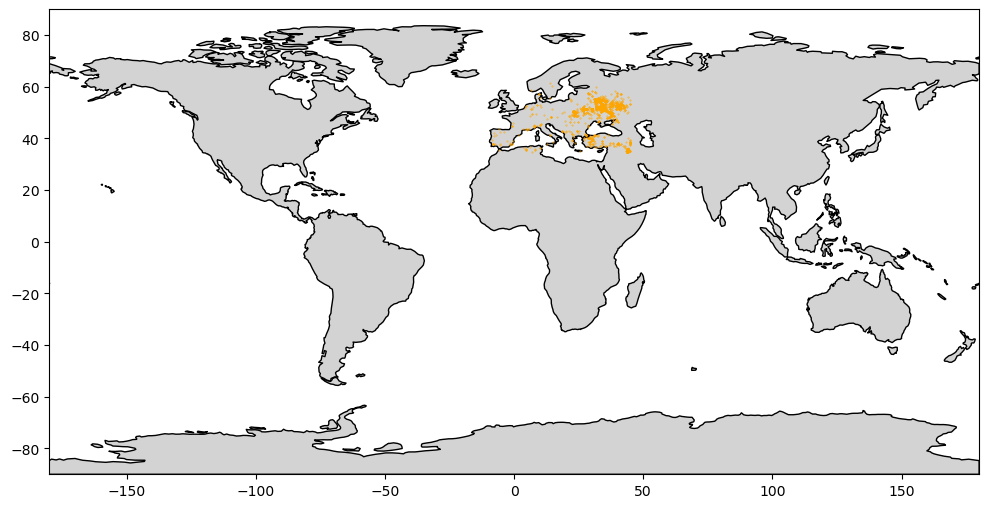

In [152]:
# We first need to import a file with global boundary geometries
path = "../data/raw/ne_110m_land/ne_110m_land.shp"
world = gpd.read_file(path).to_crs(epsg=4326)

fig, ax = plt.subplots(figsize=(12,7))

world.plot(ax=ax,
           color="lightgrey",
           edgecolor="black")

gdf.plot(ax=ax,
         color="orange",
         markersize=0.1
         )
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.set_aspect("equal")

plt.show()